In [90]:
import time
import sys
import os
import argparse
import io
from datetime import datetime
import numpy as np
import awkward
from torch_geometric.nn import DynamicEdgeConv
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from matplotlib import pyplot as plt
from torch.utils.tensorboard import SummaryWriter # to print to tensorboard
import torch.nn.functional as F
from torch_geometric.data import Data, Batch
from torch_geometric.nn import knn_graph, DynamicEdgeConv, global_mean_pool
import torch
import torch.nn as nn
from torch_geometric.nn import DynamicEdgeConv, global_mean_pool
from tqdm import tqdm

ROOT = "/home/tomas/Documents/jobb/phd-kurser/advML/A04"
DATA_PATH = os.path.join(ROOT, "DATA") 

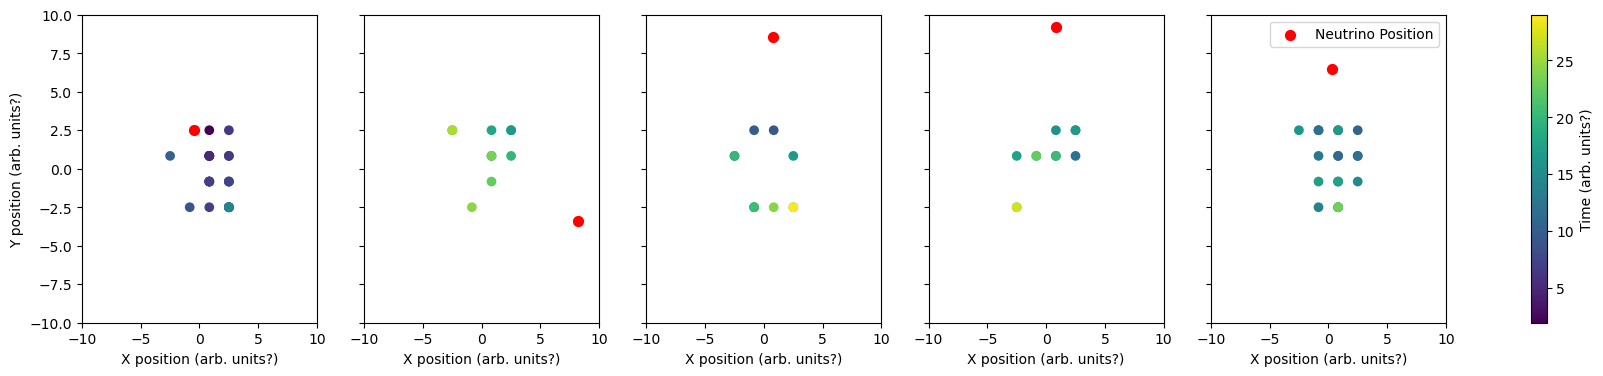

In [91]:
# Lets start by loading and looking at some data.

test_dataset = awkward.from_parquet(f'{DATA_PATH}/test.pq')
train_dataset = awkward.from_parquet(f'{DATA_PATH}/train.pq')
val_dataset = awkward.from_parquet(f'{DATA_PATH}/val.pq')

# --- collect global t range ---
t_min = np.inf
t_max = -np.inf

for k in [0, 1, 2, 3, 4]:
    temp = test_dataset[k]['data'].to_numpy()
    t = temp[0, :]
    t_min = min(t_min, t.min())
    t_max = max(t_max, t.max())

# --- plotting ---
fig, ax = plt.subplots(1, 5, figsize=(22, 4))

for k in [0, 1, 2, 3, 4]:
    temp = test_dataset[k]['data'].to_numpy()
    label = [test_dataset[k]['xpos'], test_dataset[k]['ypos']]
    x = temp[1, :]
    y = temp[2, :]
    t = temp[0, :]

    sc = ax[k].scatter(x, y, c=t, vmin=t_min, vmax=t_max)

    ax[k].scatter(label[0], label[1], c='r', s=50, label='Neutrino Position')

    l = 10
    ax[k].set_xlim(-l, +l)
    ax[k].set_ylim(-l, +l)
    ax[k].set_xlabel('X position (arb. units?)')

    if k == 0:
        ax[k].set_ylabel('Y position (arb. units?)')
    else:
        ax[k].set_yticklabels([])

# shared colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Time (arb. units?)')

plt.legend()
plt.savefig(os.path.join(ROOT, "dataset_vis.png"), dpi=300, bbox_inches='tight')
plt.show()

In [92]:
def norm_help(dataset):
    data = dataset["data"]

    t =  awkward.to_numpy(awkward.flatten(data[:, 0, :], axis=None))
    x = awkward.to_numpy(awkward.flatten(data[:, 1, :], axis=None))
    y = awkward.to_numpy(awkward.flatten(data[:, 2, :], axis=None))

    meta = {
        "t_mean": np.mean(t),"t_std":  np.std(t),"x_mean": np.mean(x),"x_std":  np.std(x),"y_mean": np.mean(y),"y_std":  np.std(y),"xlabel_mean": np.mean(awkward.to_numpy(dataset["xpos"])),
        "xlabel_std":  np.std(awkward.to_numpy(dataset["xpos"])),"ylabel_mean": np.mean(awkward.to_numpy(dataset["ypos"])),"ylabel_std":  np.std(awkward.to_numpy(dataset["ypos"])),
    }
    return meta

def normalize_dataset(dataset, meta):
    dataset = awkward.copy(dataset) #copy so that nothing is changed in the original dataset, awkward array seems to behave strange
    data = dataset["data"]
    
    
    norm_t = (data[:, 0:1, :] - meta["t_mean"]) / meta["t_std"]
    norm_x = (data[:, 1:2, :] - meta["x_mean"]) / meta["x_std"]
    norm_y = (data[:, 2:3, :] - meta["y_mean"]) / meta["y_std"]
    
    dataset["data"] = awkward.concatenate([norm_t, norm_x, norm_y], axis=1)
    dataset["xpos"] = (dataset["xpos"] - meta["xlabel_mean"]) / meta["xlabel_std"]
    dataset["ypos"] = (dataset["ypos"] - meta["ylabel_mean"]) / meta["ylabel_std"]
    
    return dataset

def denormalize_labels(labels, meta):
    labels_denorm = labels.clone() if hasattr(labels, "clone") else labels.copy()
    labels_denorm[..., 0] = labels_denorm[..., 0] * meta["xlabel_std"] + meta["xlabel_mean"]
    labels_denorm[..., 1] = labels_denorm[..., 1] * meta["ylabel_std"] + meta["ylabel_mean"]
    return labels_denorm

In [93]:
meta = norm_help(train_dataset) # meta parameters for z scaling, calculated on the training set
train_dataset_norm = normalize_dataset(train_dataset, meta)
val_dataset_norm   = normalize_dataset(val_dataset, meta)
test_dataset_norm  = normalize_dataset(test_dataset, meta)

In [94]:
# Important: We use the custom collate function to preprocess the data for GNN (see the description of the collate function for details)
def collate_fn_gnn(batch):
    """
    Custom function that defines how batches are formed.

    For a more complicated dataset with variable length per event and Graph Neural Networks,
    we need to define a custom collate function which is passed to the DataLoader.
    The default collate function in PyTorch Geometric is not suitable for this case.

    This function takes the Awkward arrays, converts them to PyTorch tensors,
    and then creates a PyTorch Geometric Data object for each event in the batch.

    You do not need to change this function.

    Parameters
    ----------
    batch : list
        A list of dictionaries containing the data and labels for each graph.
        The data is available in the "data" key and the labels are in the "xpos" and "ypos" keys.
    Returns
    -------
    packed_data : Batch
        A batch of graph data objects.
    labels : torch.Tensor
        A tensor containing the labels for each graph.
    """
    data_list = []
    labels = []

    for b in batch:
        # this is a loop over each event within the batch
        # b["data"] is the first entry in the batch with dimensions (n_features, n_hits)
        # where the feautures are (time, x, y)
        # for training a GNN, we need the graph notes, i.e., the individual hits, as the first dimension,
        # so we need to transpose to get (n_hits, n_features)
        tensordata = torch.from_numpy(b["data"].to_numpy()).T
        # the original data is in double precision (float64), for our case single precision is sufficient
        # we let's convert to single precision (float32) to save memory and computation time
        tensordata = tensordata.to(dtype=torch.float32)

        # PyTorch Geometric needs the data in a specific format
        # we need to create a PyTorch Geometric Data object for each event
        this_graph_item = Data(x=tensordata)
        data_list.append(this_graph_item)

        # also the labels need to be packaged as pytorch tensors
        labels.append(torch.Tensor([b["xpos"], b["ypos"]]).unsqueeze(0))

    labels = torch.cat(labels, dim=0) # convert the list of tensors to a single tensor
    packed_data = Batch.from_data_list(data_list) # convert the list of Data objects to a single Batch object
    return packed_data, labels
batch_size = 32

# Dataloaders based on the provided function
train_loader = DataLoader(train_dataset_norm, batch_size=batch_size, shuffle=True, collate_fn=collate_fn_gnn)
val_loader = DataLoader(val_dataset_norm, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_gnn)
test_loader = DataLoader(test_dataset_norm, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_gnn)


In [95]:
# Define the MLP class for the GNN
class MLP(nn.Module):
    def __init__(self, hidden_dim, output_dim, dropout=0.05):
        super().__init__()

        self.net = nn.Sequential(
            nn.LazyLinear(hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),

            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),

            nn.Linear(hidden_dim, output_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)
    
class GNNEncoder(nn.Module):
    def __init__(self, hidden_dim=64, k=4, dropout=0.05): 
        super().__init__()
        self.layer_list = nn.ModuleList([
            DynamicEdgeConv(
                MLP(hidden_dim=hidden_dim, output_dim=hidden_dim, dropout=dropout),
                aggr="mean",  
                k=k,
            ),
            DynamicEdgeConv(
                MLP(hidden_dim=hidden_dim, output_dim=hidden_dim, dropout=dropout),
                aggr="mean",
                k=k,
            ),
            DynamicEdgeConv(
                MLP(hidden_dim=hidden_dim, output_dim=hidden_dim, dropout=dropout),
                aggr="mean",
                k=k,
            ),
        ])
        # Tail network to predict the final labels from the graph features, we use a simple linear network for this
        self.tail = nn.Sequential(
            nn.LazyLinear(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2), # (x,y)
        )
    #standard forward stepping function
    def forward(self, data):
        x = data.x
        batch = data.batch
        #step trhough both dynamic edge layers
        for layer in self.layer_list:
            x = layer(x, batch)

        x = global_mean_pool(x, batch) # as example
        x = self.tail(x)           #step through the "final" dense network
        return x

In [96]:
num_epoch = 150
# Model initialization
device = torch.device("cpu")
model = GNNEncoder()
loss_func = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=5e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epoch, eta_min=1e-6)

/home/tomas/.local/lib/python3.10/site-packages/torch/nn/modules/lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


In [97]:


# Training
train_losses, val_losses = [], []
best_val_loss = float('inf')
best_path = os.path.join(ROOT, "best_model.pth")

for epoch in range(num_epoch):
    print(f"Epoch {epoch+1}, LR: {scheduler.get_last_lr()[0]:.6f}")
    model.train()
    train_loss = 0
    for batch, labels in tqdm(train_loader):
        batch = batch.to(device)
        labels = labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        predictions = model(batch)
        loss = loss_func(predictions, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    print(f"Loss {train_loss:.3f} Epoch {epoch+1}")

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch, labels in val_loader:
            batch = batch.to(device)
            labels = labels.to(device)
            predictions = model(batch)
            loss = loss_func(predictions, labels)
            val_loss += loss.item()
        val_loss /= len(val_loader)
        val_losses.append(val_loss)
    print(f"Val Loss {val_loss:.3f} Epoch {epoch+1}")

            # ---- Save best ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_path)
        print(f"✅ Saved new best model (val_loss={val_loss:.4f})")

    # Step the scheduler after each epoch
    scheduler.step()

Epoch 1, LR: 0.005000


100%|██████████| 313/313 [00:08<00:00, 37.18it/s]


Loss 0.295 Epoch 1
Val Loss 0.223 Epoch 1
✅ Saved new best model (val_loss=0.2232)
Epoch 2, LR: 0.004999


100%|██████████| 313/313 [00:08<00:00, 37.48it/s]


Loss 0.210 Epoch 2
Val Loss 0.208 Epoch 2
✅ Saved new best model (val_loss=0.2076)
Epoch 3, LR: 0.004998


...

Loss 0.052 Epoch 148
Val Loss 0.082 Epoch 148
Epoch 149, LR: 0.000003


100%|██████████| 313/313 [00:10<00:00, 31.21it/s]


Loss 0.052 Epoch 149
Val Loss 0.082 Epoch 149
Epoch 150, LR: 0.000002


100%|██████████| 313/313 [00:09<00:00, 31.60it/s]


Loss 0.053 Epoch 150
Val Loss 0.082 Epoch 150


In [98]:
all_pred = []
all_true = []
# Validation data (assuming val_loader; change to test_loader if needed)
model.eval()
with torch.no_grad():
    for batch, labels in val_loader:
        batch = batch.to(device)
        labels = labels.to(device)
        predictions = model(batch)
        
        all_pred.append(predictions.cpu())  # move to CPU to save GPU memory
        all_true.append(labels.cpu())

# Concatenate all batches into single tensors, then convert to numpy
all_pred = torch.cat(all_pred, dim=0).numpy()
all_true = torch.cat(all_true, dim=0).numpy()

# Rescale back to original units using training mean/std
all_pred_original = denormalize_labels(torch.from_numpy(all_pred), meta).numpy()
all_true_original = denormalize_labels(torch.from_numpy(all_true), meta).numpy()

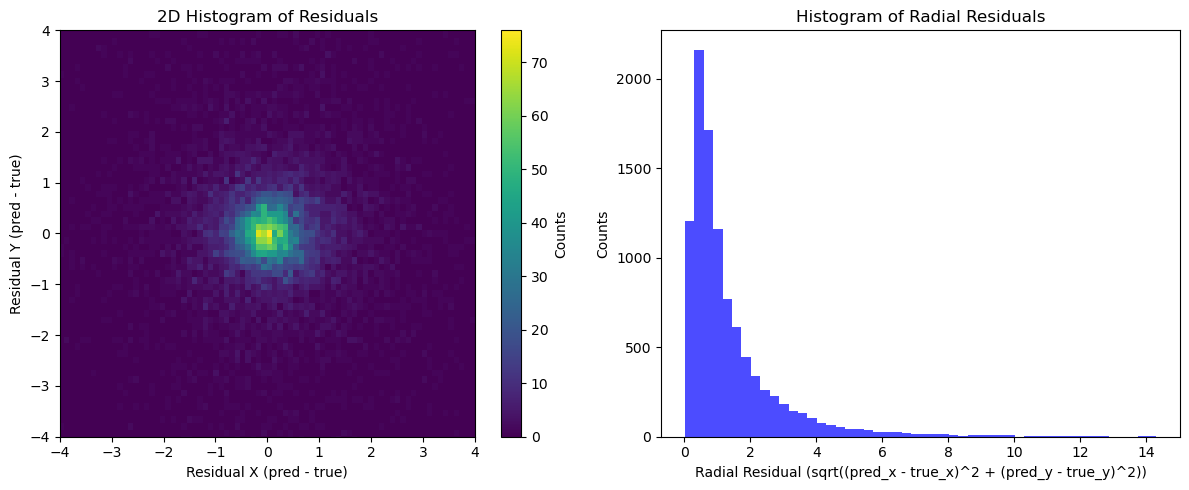

In [99]:
# 2d histogram of residuals and radial average of residuals
residuals_x = all_pred_original[:, 0] - all_true_original[:, 0]
residuals_y = all_pred_original[:, 1] - all_true_original[:, 1]
residuals_radial = np.sqrt(residuals_x**2 + residuals_y**2)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist2d(residuals_x, residuals_y, bins=200, cmap='viridis')
l = 4
plt.xlim(-l, +l)
plt.ylim(-l, +l)
plt.colorbar(label='Counts')
plt.xlabel('Residual X (pred - true)')
plt.ylabel('Residual Y (pred - true)')
plt.title('2D Histogram of Residuals')
plt.subplot(1, 2, 2)
plt.hist(residuals_radial, bins=50, color='blue', alpha=0.7)
plt.xlabel('Radial Residual (sqrt((pred_x - true_x)^2 + (pred_y - true_y)^2))')
plt.ylabel('Counts')
plt.title('Histogram of Radial Residuals')
plt.tight_layout()
plt.savefig(os.path.join(ROOT, "residuals.png"),dpi=300)
plt.show()


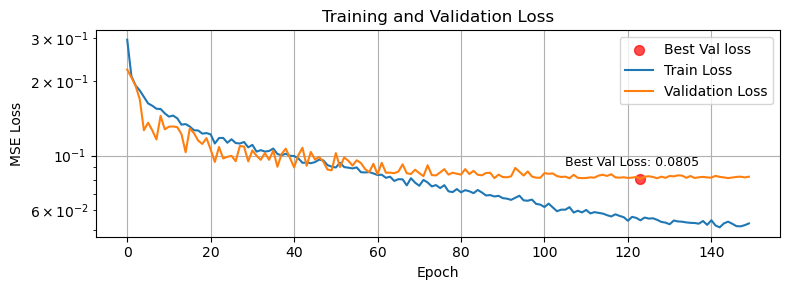

In [100]:
# train and val losses
plt.figure(figsize=(8, 3))
plt.scatter(np.argmin(val_losses), best_val_loss, color='red', s=50, label='Best Val loss',alpha=0.7)
plt.text(np.argmin(val_losses)-20, 1.1*best_val_loss, f'  Best Val Loss: {best_val_loss:.4f}', va='bottom', ha='left', fontsize=9)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig(os.path.join(ROOT, "losses.png"),dpi=300)
plt.show()  